In [1]:
import os

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
base_path = "archive"

for split in ["train", "valid", "test"]:
    split_path = os.path.join(base_path, split)
    print(f"\n{split.upper()}:")

    classes = os.listdir(split_path)
    print(f"Classes ({len(classes)}): {classes}")


TRAIN:
Classes (2): ['1', '0']

VALID:
Classes (2): ['1', '0']

TEST:
Classes (2): ['1', '0']


In [4]:
def get_class_distribution(path):
    counts = {}
    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_dist = get_class_distribution(os.path.join(base_path, "train"))

print("Train Distribution:", train_dist)

Train Distribution: {'1': 803, '0': 1569}


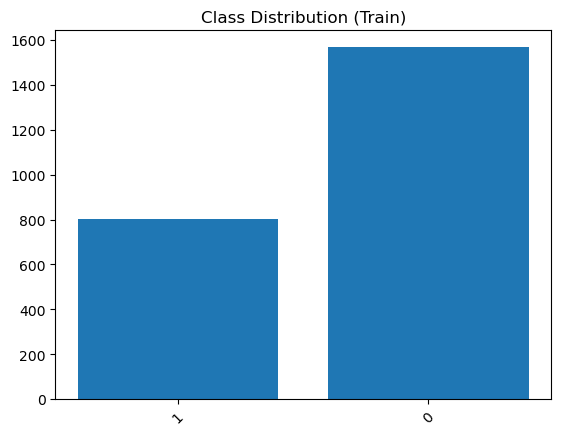

In [5]:
plt.bar(train_dist.keys(), train_dist.values())
plt.xticks(rotation=45)
plt.title("Class Distribution (Train)")
plt.show()

In [6]:
def get_image_sizes(path, max_samples=200):
    sizes = []
    count = 0

    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            try:
                with Image.open(img_path) as img:
                    sizes.append(img.size)  # (width, height)
                count += 1
                if count >= max_samples:
                    return sizes
            except:
                continue
    return sizes

sizes = get_image_sizes(os.path.join(base_path, "train"))

print("Sample image sizes:", sizes[:10])

Sample image sizes: [(640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640)]


In [7]:
def check_corrupted_images(path):
    corrupted = []

    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except:
                corrupted.append(img_path)

    return corrupted

corrupted_images = check_corrupted_images(os.path.join(base_path, "train"))

print("Corrupted images:", len(corrupted_images))

Corrupted images: 0


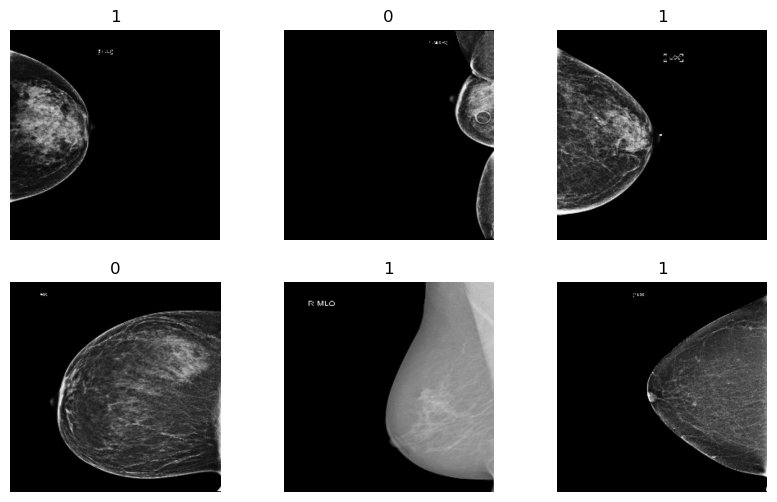

In [8]:
import random

def show_samples(path, num_samples=6):
    classes = os.listdir(path)
    plt.figure(figsize=(10, 6))

    for i in range(num_samples):
        cls = random.choice(classes)
        cls_path = os.path.join(path, cls)
        img_name = random.choice(os.listdir(cls_path))
        img_path = os.path.join(cls_path, img_name)

        img = Image.open(img_path)

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

    plt.show()

show_samples(os.path.join(base_path, "train"))

In [9]:
from torchvision import transforms

# For minority class (class 1) → stronger augmentation
minority_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# For majority class (class 0) → lighter augmentation
majority_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [10]:
from torch.utils.data import Dataset
from PIL import Image
import os

class CustomDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        self.root_dir = root_dir

        for label in os.listdir(root_dir):
            label_path = os.path.join(root_dir, label)
            for img_name in os.listdir(label_path):
                self.samples.append((os.path.join(label_path, img_name), int(label)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if label == 1:
            image = minority_transform(image)
        else:
            image = majority_transform(image)

        return image, label